In [16]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]]
y_iris = iris.target
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(random_state=42)

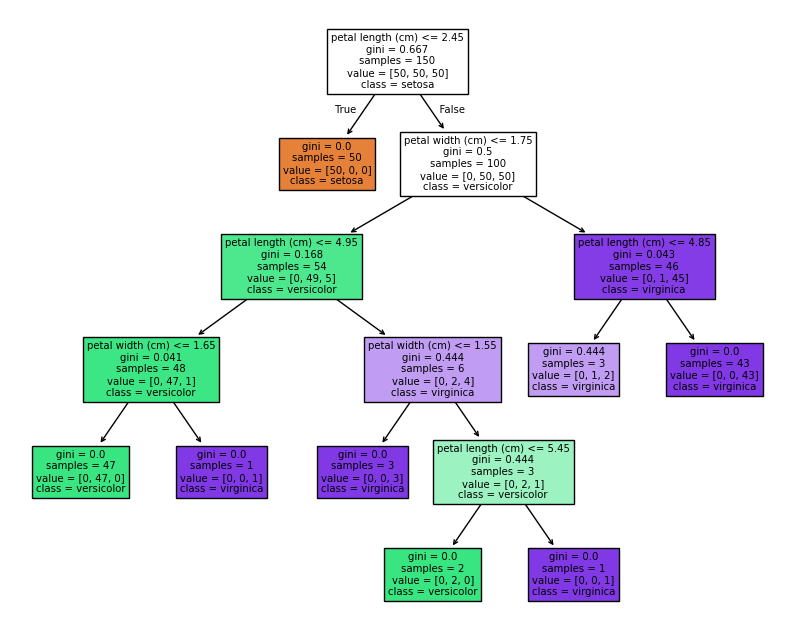

In [17]:
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_tree(tree_clf, feature_names=X_iris.columns, class_names=iris.target_names, filled=True)
plt.show()

In [ ]:
# 지니계수: 데이터의 순도 측정하는 지표
# 순도가 높다: 집단 안에 같은 종류의 데이터만 모여있다 (지니계수 낮음)
# 불순도가 높다: 여러 종류의 데이터가 마구 섞여 있다 (지니계수 높음)
# 데이터를 분할할때마다 지니계수가 낮아지는 방향으로 가지를 뻗는다



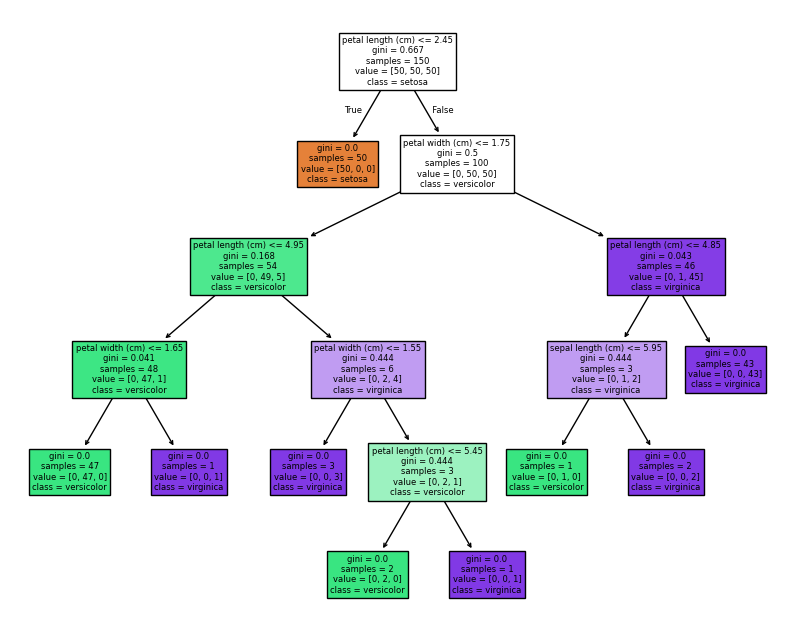

In [18]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris(as_frame=True)
X_iris = iris.data.copy()
y_iris = iris.target
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_iris, y_iris)

from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_tree(tree_clf, feature_names=X_iris.columns, class_names=iris.target_names, filled=True)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import  classification_report
X_train, X_test, y_train, y_test \
    = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42,stratify=y_iris)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(tree_clf.feature_importances_,tree_clf.feature_names_in_)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

[0.00625    0.02916667 0.5585683  0.40601504] ['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']


In [20]:
from sklearn.svm import SVC
svm_clf = SVC(random_state=42, kernel="rbf")
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



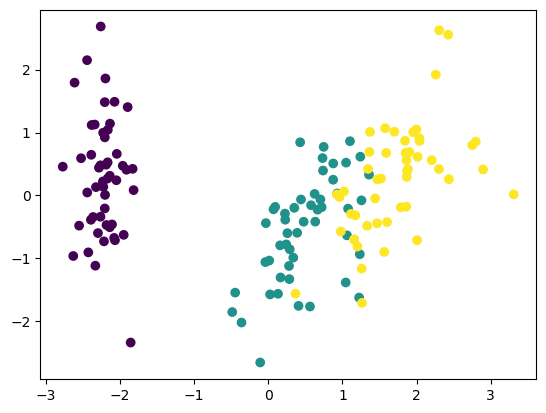

In [21]:
# PCA 주성분 분석
# 데이터의 분산이 가장 큰 방향으로 축을 만들어 데이터를 투영하는 방법

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
iris = load_iris()
pca = PCA(n_components=2, random_state=42)
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('pca',PCA(n_components=2))
])
X =  pipeline.fit_transform(iris.data)
y = iris.target
plt.scatter(X[:,0], X[:,1],c=y)
plt.show()

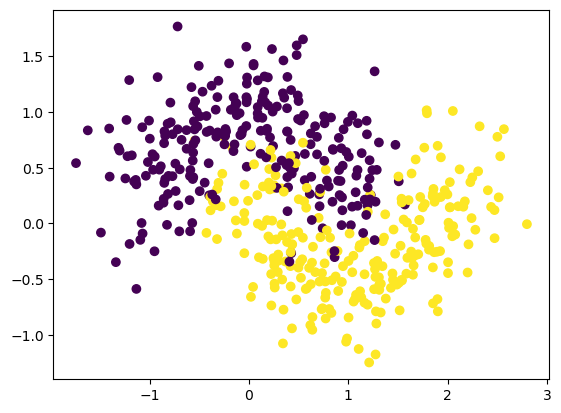

In [22]:
# Voting 투표기반
from sklearn.datasets import make_moons
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt

X,y = make_moons(n_samples=500, noise=0.3, random_state=42)
plt.scatter(X[:,0], X[:,1],c=y)
plt.show()

In [23]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
models = [RandomForestClassifier(random_state=42), 
          LogisticRegression(random_state=42), SVC(random_state=42)]
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y)
for model in models:
    model.fit(x_train,y_train)
    y_predict = model.predict(x_test)
    print(classification_report(y_test, y_predict))

hard_votiong = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc',SVC(random_state=42))
    ],
    voting='hard'
)
hard_votiong.fit(x_train,y_train)
y_predict = hard_votiong.predict(x_test)
print('-'*50)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        63
           1       0.90      0.90      0.90        62

    accuracy                           0.90       125
   macro avg       0.90      0.90      0.90       125
weighted avg       0.90      0.90      0.90       125

              precision    recall  f1-score   support

           0       0.83      0.84      0.83        63
           1       0.84      0.82      0.83        62

    accuracy                           0.83       125
   macro avg       0.83      0.83      0.83       125
weighted avg       0.83      0.83      0.83       125

              precision    recall  f1-score   support

           0       0.88      0.95      0.92        63
           1       0.95      0.87      0.91        62

    accuracy                           0.91       125
   macro avg       0.91      0.91      0.91       125
weighted avg       0.91      0.91      0.91       125

-------------------

In [24]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train,y_train)
import numpy as np
np.argmax(rfc.predict_proba(x_test),axis=1)[:5] , rfc.predict(x_test)[:5]

(array([1, 1, 0, 1, 0], dtype=int64), array([1, 1, 0, 1, 0], dtype=int64))